# 🌌 Project Overview: Support Vector Machine (SVM) Stellar Classification

This project uses the **Support Vector Machine (SVM)** algorithm to solve a **binary classification** problem: distinguishing between **Giant** and **Dwarf** stars based on stellar properties. The dataset provides raw and calculated features relevant to the Morgan-Keenan (MK) stellar classification system.

---

## 🔬 Ex 1.1: Data Exploration and Preprocessing

| ML/Data Science Principle | Concept | Goal |
| :--- | :--- | :--- |
| **Exploratory Data Analysis (EDA)** | **Pairplot Visualization** | Visualizing the relationships between all feature pairs, color-coded by the target class. This helps determine which features show the best **linear or non-linear separation** between Dwarf and Giant stars, guiding feature selection. |
| **Target Distribution Analysis** | **Class Imbalance Detection** | Plotting the **histogram of target labels**. An imbalanced distribution (many more stars in one class than the other) is a critical issue that can lead to a model biased toward the majority class, hindering overall generalization. |
| **Feature Transformation** | **Label Encoding** | Converting the categorical target labels ('Dwarf', 'Giant') into a numerical format (0, 1), which is required for most ML algorithms. |

---

## 📈 Ex 1.2 & 1.3: Modeling and Hyperparameter Optimization

The core of the exercise is establishing a baseline model and systematically optimizing its performance.

| Task | ML/Data Science Principle | Concept Demonstrated |
| :--- | :--- | :--- |
| **Ex. 1.2** | **Baseline Model & Train-Test Protocol** | **Simplest Workflow:** Training a default SVM model using a simple train-test split and the **Accuracy** metric. This provides a **performance baseline** against which tuned models can be compared. |
| **Ex. 1.3** | **Hyperparameter Tuning (Grid Search CV)** | **Systematic Optimization:** Using **Grid Search with Cross-Validation (CV)** to find the optimal combination of the **C** (regularization) and **kernel** (decision boundary type) hyperparameters. CV ensures the selected parameters generalize well by testing them across multiple folds of the training data. |
| **Ex. 1.3** | **Final Performance Assessment** | **Hold-out Test Set Evaluation:** The optimal model is rigorously evaluated on a **completely unseen** hold-out test set using **Accuracy, Classification Report, and Confusion Matrix**. The comparison of Ex. 1.2 (default) and Ex. 1.3 (tuned) accuracies quantifies the value of hyperparameter tuning. |

---

## 🔭 Ex 1.4 & 1.5: Feature Selection and Visualization

These bonus tasks tie the ML process directly back to the underlying astrophysics principles.

| Task | ML/Data Science Principle | Concept Demonstrated |
| :--- | :--- | :--- |
| **Ex. 1.4 [Bonus]** | **Feature Selection / Dimensionality Reduction** | **Domain-Driven Feature Selection:** Training the SVM only on 'Amag', 'Temp/Teff', and 'Luminosity'. This is a physical restriction, as these features are key to the **Hertzsprung-Russell (HR) diagram**, the most fundamental tool for stellar classification. Comparing this accuracy to the full-feature model (Ex 1.3) verifies if the full feature set is truly necessary or if the underlying physics can be captured by a minimal set. |
| **Ex. 1.5 [Bonus]** | **Decision Boundary Visualization** | **Model Interpretability:** Plotting the **decision function** of the best models in the **Surface Temperature vs. Luminosity** space. This visualization connects the abstract mathematical SVM decision boundary directly to the physical **HR Diagram**, providing a clear interpretation of how the model separates the stellar classes. |

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

/home/erebus/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Ex1.1

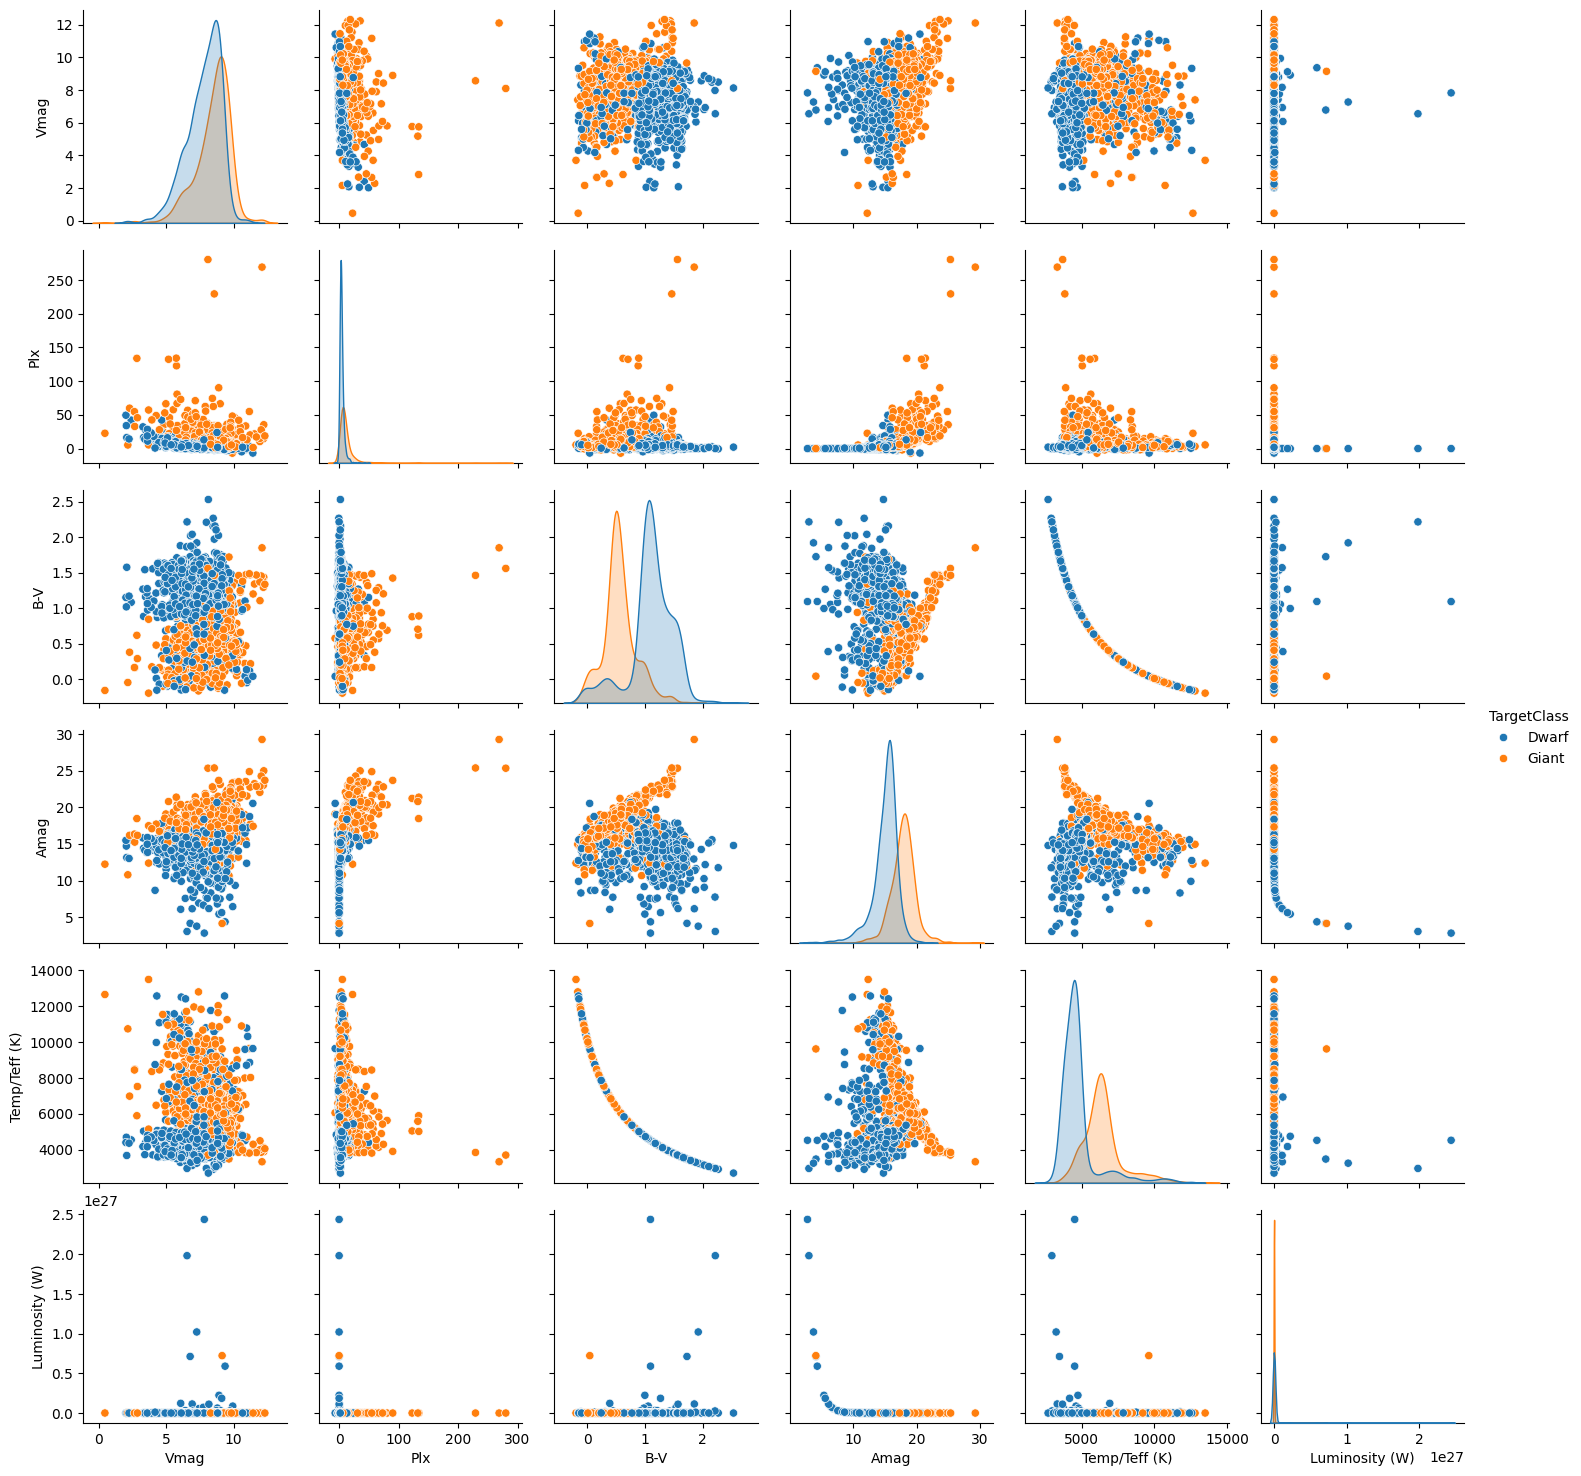

In [2]:
data = pd.read_csv("HW04_data.csv")

# seaborn pairplot
sns.pairplot(data, hue="TargetClass", vars=["Vmag", "Plx", "B-V", "Amag", "Temp/Teff (K)", "Luminosity (W)",])
plt.show()

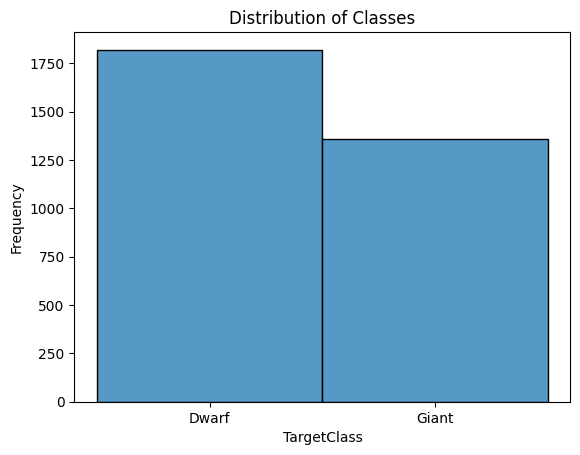

In [3]:
# histogram
sns.histplot(data['TargetClass'], bins=2, kde=False)
plt.title("Distribution of Classes")
plt.xlabel("TargetClass")
plt.ylabel("Frequency")
plt.xticks([0, 1], ['Dwarf', 'Giant'])  
plt.show()

The class Dwarf seems to appear more often than the class Giant.This may result in a model that is biased towards the class Dwarf as  it may learn to favor that class when making predictions.

In [4]:

#numerical class column
data["class_numeric"] = data["TargetClass"].map({"Dwarf": 0, "Giant": 1})

# Ex1.2

In [5]:
X = data.drop(columns=["TargetClass", "class_numeric"])
y = data['TargetClass'] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
#accuracy metric for assessment
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.89937106918239


# Ex1.3

In [6]:
#hyperparameter tuning
param_grid = {
    'C': [1,5,10],
    'kernel': ['linear', 'rbf','poly'],}

GridSearch = GridSearchCV(model, param_grid, cv=5)
GridSearch.fit(X_train, y_train)

print("Best parameters:", GridSearch.best_params_)

print("Best score:", GridSearch.best_score_)

bestmodel = GridSearch.best_estimator_
y_pred = bestmodel.predict(X_test)
#accuracy metric for assessment
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,
 y_pred))

Best parameters: {'C': 1, 'kernel': 'rbf'}
Best score: 0.9025145800782759
Accuracy: 0.89937106918239
Classification Report:
               precision    recall  f1-score   support

       Dwarf       0.90      0.93      0.91       362
       Giant       0.90      0.86      0.88       274

    accuracy                           0.90       636
   macro avg       0.90      0.90      0.90       636
weighted avg       0.90      0.90      0.90       636

Confusion Matrix:
 [[335  27]
 [ 37 237]]


The accuracies from Ex 1.2 and Ex 1.3 are exactly the same. This seems to be  because the default hyperparameters of the SVM model are the same as the optimal hyperparameters found by the GridSearchCV.

# Ex1.4

In [7]:
X2 = data[['Amag', 'Temp/Teff (K)', 'Luminosity (W)']]
y2 = data['TargetClass']

scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(X2)


X_train2, X_test2, y_train2, y_test2 = train_test_split(X_scaled2, y2, test_size=0.2, random_state=42)

model2 = SVC()

model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

acc2 = accuracy_score(y_test2, y_pred2)

print("Accuracy:", acc2)
param_grid2 = {
    'C': [1,5,10],
    'kernel': ['linear', 'rbf','poly'],}

GridSearch2 = GridSearchCV(model, param_grid, cv=5)
GridSearch2.fit(X_train2, y_train2)

print("Best parameters:", GridSearch2.best_params_)


print("Best score:", GridSearch2.best_score_)

bestmodel2 = GridSearch2.best_estimator_
y_pred2 = bestmodel2.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)
print("Accuracy:", accuracy2)
print("Classification Report:\n", classification_report(y_test2, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test2,
 y_pred2))

Accuracy: 0.9040880503144654
Best parameters: {'C': 5, 'kernel': 'rbf'}
Best score: 0.898979781260152
Accuracy: 0.9056603773584906
Classification Report:
               precision    recall  f1-score   support

       Dwarf       0.91      0.93      0.92       362
       Giant       0.90      0.88      0.89       274

    accuracy                           0.91       636
   macro avg       0.91      0.90      0.90       636
weighted avg       0.91      0.91      0.91       636

Confusion Matrix:
 [[336  26]
 [ 34 240]]


Generally if all the dataset would be equally informative we would expect a decrease in the accuracy. However, since we observe an increase in accuracy, we can conclude that the excluded data may add noise or contain less relevant information for this classification task and the data columns used in 1.4 are more suitable for distinguishing whether a star belongs in the dwarf or Giant class